# 17 — Convolution Forward Pass

This notebook turns the shape reasoning from Notebook 16 into a complete naive convolution forward pass. The implementation uses explicit loops so every output value can be connected to its input patch and filter.

## Learning objectives

- apply zero-padding to an NCHW image batch;
- map an output coordinate to the corresponding input window;
- calculate one response across all input channels;
- implement a batched, multi-filter convolution forward pass;
- verify the implementation with small deterministic examples;
- visualize feature maps produced by hand-designed filters;
- identify what must be cached for the backward pass.

In [3]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=2, suppress=True)

## 1. Forward-pass contract

We use the channels-first convention:

$$
X:(N,C,H,W),\qquad W_f:(F,C,HH,WW),\qquad b:(F).
$$

Here $W_f$ denotes the complete filter bank, not the input width. The output has shape

$$
Y:(N,F,H_{out},W_{out}).
$$

For output location $(n,f,i,j)$, the filter's top-left padded-input coordinate is

$$
h_{start}=iS,\qquad w_{start}=jS.
$$

$S$ is the **stride**: the number of input positions the filter moves between neighboring output positions. For example, with $S=2$, output rows $i=0,1,2$ start at padded-input rows $0,2,4$. These formulas use padded-input coordinates; relative to the original unpadded input, the starts would be $iS-P$ and $jS-P$.

The output value is

$$
Y_{n,f,i,j}=\sum_{c,u,v}X_{pad}[n,c,h_{start}+u,w_{start}+v]W_f[f,c,u,v]+b_f.
$$

In [4]:
def convolution_output_shape(
    input_height, input_width, filter_height, filter_width, padding, stride
):
    """Return spatial output shape when the filters tile exactly."""
    if not isinstance(stride, (int, np.integer)) or isinstance(
        stride, (bool, np.bool_)
    ) or stride <= 0:
        raise ValueError("stride must be a positive integer")
    if not isinstance(padding, (int, np.integer)) or isinstance(
        padding, (bool, np.bool_)
    ) or padding < 0:
        raise ValueError("padding must be a nonnegative integer")

    height_travel = input_height + 2 * padding - filter_height
    width_travel = input_width + 2 * padding - filter_width
    if height_travel < 0 or width_travel < 0:
        raise ValueError("filter cannot be larger than the padded input")
    if height_travel % stride != 0 or width_travel % stride != 0:
        raise ValueError("filters must tile the padded input exactly")

    return 1 + height_travel // stride, 1 + width_travel // stride

## 2. Zero-padding

Padding $P$ adds $P$ rows above and below and $P$ columns left and right. The batch and channel axes do not change:

$$
(N,C,H,W)\longrightarrow(N,C,H+2P,W+2P).
$$

`np.pad` accepts one `(before, after)` pair per axis. For NCHW data, only the last two pairs should be nonzero.

### Exercise 1 — Pad a batch

Add one zero-valued border around the spatial dimensions. Check that the original batch appears unchanged in the center.

In [8]:
x_small = np.arange(2 * 1 * 3 * 4).reshape(2, 1, 3, 4)
padding = 1

# pad neither the batch nor channel dimension.
x_padded = np.pad(x_small, ((0, 0), (0, 0), (padding, padding), (padding, padding)))

assert x_padded.shape == (2, 1, 5, 6)
assert np.array_equal(x_padded[:, :, 1:-1, 1:-1], x_small)
assert np.count_nonzero(x_padded[:, :, 0, :]) == 0
x_padded[0, 0]

array([[ 0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  2,  3,  0],
       [ 0,  4,  5,  6,  7,  0],
       [ 0,  8,  9, 10, 11,  0],
       [ 0,  0,  0,  0,  0,  0]])

## 3. From output coordinates to an input patch

Stride belongs in the mapping from an **output index** to an **input start index**. If stride is 2, output row 3 begins at padded-input row $3\cdot2=6$. The window ends one filter height later; Python's slice endpoint is exclusive.

### Exercise 2 — Extract one receptive field

For output coordinate `(output_row=1, output_col=2)`, stride 2, and a $2\times3$ filter, calculate the start and end indices and extract the complete multi-channel patch.

In [ ]:
example = np.arange(1 * 2 * 6 * 8).reshape(1, 2, 6, 8)
output_row, output_col = 1, 2
stride = 2
filter_height, filter_width = 2, 3

# map the output coordinate to padded-input slice boundaries.
height_start = output_row*stride
width_start = output_col*stride
height_end = height_start + filter_height
width_end = width_start + filter_width
patch = example[0][:, height_start:height_end, width_start:width_end]

assert (height_start, width_start) == (2, 4)
assert patch.shape == (2, 2, 3)
assert np.array_equal(patch, example[0, :, 2:4, 4:7])
patch

array([[[20, 21, 22],
        [28, 29, 30]],

       [[68, 69, 70],
        [76, 77, 78]]])

## 4. One output value

A patch and one filter have the same shape $(C,HH,WW)$. Their elementwise product is summed over every channel and spatial position, after which one scalar filter bias is added.

This operation produces exactly one value—not one value per input channel—because the channel contributions are summed together.

### Exercise 3 — Write a single-position helper

Complete the helper and use it on a two-channel patch. Keep the calculation visibly close to the equation.

In [15]:
def convolution_response(patch, one_filter, bias):
    """Return one scalar convolution response."""
    # sum the elementwise product and add the scalar bias.
    return np.sum(patch * one_filter) + bias
    # return np.vdot(patch, one_filter) + bias


test_patch = np.array(
    [[[1, 2], [3, 4]], [[0, 1], [1, 0]]], dtype=np.float64
)
test_filter = np.array(
    [[[1, 0], [0, -1]], [[2, 2], [2, 2]]], dtype=np.float64
)
test_response = convolution_response(test_patch, test_filter, bias=0.5)
assert np.isscalar(test_response)
assert np.isclose(test_response, 1.5)
test_response

np.float64(1.5)

## 5. Assemble the complete forward pass

The naive implementation needs four loops:

1. select an image $n$;
2. select a filter $f$;
3. select an output row $i$;
4. select an output column $j$.

There is no channel loop because NumPy multiplies and sums the complete channel depth of the patch at once. The loop order may differ without changing the result.

The forward pass should cache values needed later by the backward pass. We will cache the original input, filters, biases, stride, and padding.

### Exercise 4 — Implement naive convolution

Complete the missing validation, output allocation, loop boundaries, patch extraction, and output assignment. Do not flip the filters.

In [32]:
def conv_forward_naive(x, weights, bias, *, stride=1, padding=0):
    """Compute a naive NCHW convolution forward pass."""
    if x.ndim != 4 or weights.ndim != 4 or bias.ndim != 1:
        raise ValueError("x and weights must be 4D; bias must be 1D")

    num_examples, input_channels, input_height, input_width = x.shape
    num_filters, filter_channels, filter_height, filter_width = weights.shape

    # verify channel and bias compatibility.
    if bias.shape[0] != num_filters:
        raise ValueError("bias must contain one value per filter")
    if input_channels != filter_channels:
        raise ValueError(
            "each filter must have the same number of channels as the input"
        )

    output_height, output_width = convolution_output_shape(
        input_height, input_width, filter_height, filter_width, padding, stride
    )
    x_padded = np.pad(
        x, ((0, 0), (0, 0), (padding, padding), (padding, padding))
    )

    # allocate output using a dtype that preserves numeric precision.
    output_dtype = np.result_type(
        x.dtype,
        weights.dtype,
        bias.dtype,
        np.float32,
    )
    output = np.zeros((num_examples, num_filters, output_height, output_width), dtype=output_dtype)

    for example_index in range(num_examples):
        for filter_index in range(num_filters):
            for output_row in range(output_height):
                # calculate this row's input slice.
                height_start = output_row*stride
                height_end = height_start + filter_height
                for output_col in range(output_width):
                    # calculate this column's input slice.
                    width_start = output_col*stride
                    width_end = width_start + filter_width
                    # extract all channels and assign one response.
                    patch = x_padded[example_index][:, height_start:height_end, width_start:width_end]
                    output[example_index, filter_index, output_row, output_col] = convolution_response(patch, weights[filter_index], bias[filter_index])

    cache = (x, weights, bias, stride, padding)
    return output, cache

### Exercise 5 — Verify a deterministic example

Apply two $2\times2$ filters to one $4\times4$ single-channel image. Before running the test, explain why the first feature map should contain only `-5`.

In [33]:
known_x = np.arange(1, 17, dtype=np.float64).reshape(1, 1, 4, 4)
known_weights = np.array(
    [
        [[[1, 0], [0, -1]]],
        [[[1, 1], [1, 1]]],
    ],
    dtype=np.float64,
)
known_bias = np.array([0.0, 0.5])
known_output, known_cache = conv_forward_naive(
    known_x, known_weights, known_bias, stride=1, padding=0
)
expected_output = np.array(
    [
        [
            [[-5, -5, -5], [-5, -5, -5], [-5, -5, -5]],
            [[14.5, 18.5, 22.5], [30.5, 34.5, 38.5], [46.5, 50.5, 54.5]],
        ]
    ]
)

assert known_output.shape == (1, 2, 3, 3)
assert np.allclose(known_output, expected_output)
assert known_cache[0] is known_x
known_output

array([[[[-5. , -5. , -5. ],
         [-5. , -5. , -5. ],
         [-5. , -5. , -5. ]],

        [[14.5, 18.5, 22.5],
         [30.5, 34.5, 38.5],
         [46.5, 50.5, 54.5]]]])

every $2\times2$ patch has the form
$
\begin{bmatrix}
a & a+1\\
a+4 & a+5
\end{bmatrix}.
$

The first filter calculates $a-(a+5)=-5$, so every response is -5.

## 6. Stride and padding checks

A correct implementation must work beyond the easiest stride-1, no-padding case. We can also test parameter sharing directly: identical patches at different locations must produce identical responses from the same filter.

### Exercise 6 — Test shapes and shared responses

Create an input with two identical $2\times2$ blocks separated spatially. Apply one $2\times2$ filter with stride 2. Also run a separate padded shape check.

In [ ]:
shared_x = np.array(
    [[[[1, 2, 1, 2], [3, 4, 3, 4], [0, 0, 0, 0], [0, 0, 0, 0]]]],
    dtype=np.float64,
)
shared_weights = np.array([[[[1, -1], [1, -1]]]], dtype=np.float64)
shared_bias = np.zeros(1)
shared_output, _ = conv_forward_naive(
    shared_x, shared_weights, shared_bias, stride=2, padding=0
)

# The top-left and top-right patches are identical:
# [[1, 2],
# [3, 4]]
assert shared_output.shape == (1, 1, 2, 2)
assert np.isclose(shared_output[0, 0, 0, 0], shared_output[0, 0, 0, 1])

padded_x = np.ones((2, 3, 5, 5))
padded_weights = np.ones((4, 3, 3, 3))
padded_bias = np.zeros(4)
padded_output, _ = conv_forward_naive(
    padded_x, padded_weights, padded_bias, stride=1, padding=1
)
assert padded_output.shape == (2, 4, 5, 5)
print("Stride, padding, and parameter-sharing checks passed.")

Stride, padding, and parameter-sharing checks passed.


## 7. Visualize feature maps

Hand-designed filters make the spatial meaning of the output easier to inspect. The following image contains a bright rectangle. One filter compares left and right values; the other compares upper and lower values. The signs of their responses depend on edge direction.

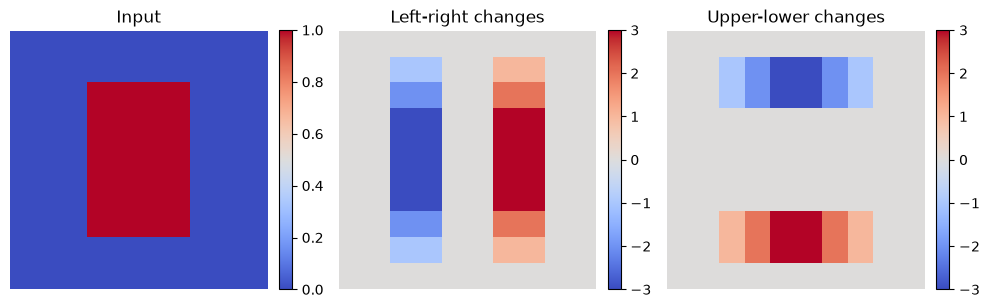

In [35]:
edge_image = np.zeros((1, 1, 10, 10), dtype=np.float64)
edge_image[0, 0, 2:8, 3:7] = 1.0
edge_filters = np.array(
    [
        [[[1, 0, -1], [1, 0, -1], [1, 0, -1]]],
        [[[1, 1, 1], [0, 0, 0], [-1, -1, -1]]],
    ],
    dtype=np.float64,
)
edge_maps, _ = conv_forward_naive(
    edge_image, edge_filters, np.zeros(2), stride=1, padding=1
)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
arrays = (edge_image[0, 0], edge_maps[0, 0], edge_maps[0, 1])
titles = ("Input", "Left-right changes", "Upper-lower changes")
for axis, array, title in zip(axes, arrays, titles):
    image = axis.imshow(array, cmap="coolwarm")
    axis.set_title(title)
    axis.axis("off")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Exercise 7 — Interpret the feature maps

Add a short Markdown cell explaining:

1. where each filter produces large positive and negative responses;
2. why uniform regions produce responses near zero;
3. why the feature-map shape matches the input shape;
4. whether the filter itself understands the concept of a rectangle.

1. at positions where there is color change at image
2. sam color values give sum 0 after multoplied to filter 
3. stride=1, padding=1
4. no, one filter see only horisontal change, onother vertical

## Reflection

Add a Markdown cell answering:

1. What does one value `output[n, f, i, j]` represent?
2. How is `(i, j)` mapped to a padded-input window when stride is $S$?
3. Why does the patch include every input channel?
4. Why is there one bias per filter rather than one bias per spatial position?
5. Which dimensions are preserved by zero-padding, and which grow?
6. Why is no explicit channel loop required in this implementation?
7. How does this code demonstrate parameter sharing?
8. Why does increasing the number of filters increase output depth?
9. What information must the forward pass cache for backpropagation?
10. Why is this naive implementation useful even though optimized libraries are faster?
11. What errors could produce the correct output shape but incorrect values?
12. Which part of the four-loop implementation was hardest to reason about?

The next notebook will derive `dx`, `dweights`, and `dbias` and implement the matching naive convolution backward pass.

1. One value `output[n, f, i, j]` is filter $f$'s response to the local patch at spatial position $(i,j)$ in image $n$.
2. The padded-input window starts at `(i * S, j * S)` and extends by the filter height and width.
3. A filter combines all features available at one location, so its patch must include every input channel.
4. One filter uses the same weights and bias everywhere; one bias per position would break that parameter sharing.
5. Padding preserves the batch and channel dimensions. It increases both spatial dimensions by $2P$.
6. NumPy multiplies the complete $(C,HH,WW)$ patch and filter at once, and `np.sum` reduces all three dimensions.
7. The same `weights[filter_index]` and `bias[filter_index]` are used for every output row and column.
8. Each filter produces one feature map, so $F$ filters produce $F$ output channels.
9. Backpropagation needs the original input, filters, biases, stride, and padding.
10. The explicit implementation exposes the indexing, shape transformations, and parameter sharing hidden by optimized libraries.
11. Incorrect stride indexing, wrong slice endpoints, omitted channels, flipped filters, wrong padding, or adding the wrong bias could preserve the shape while changing values.
12. The hardest part was mapping each output row and column to the correct padded-input slice inside the nested loops.